# AnalystLab Africa - Week 3: Machine Learning Fundamentals

## 📖 Concept 1: Supervised vs. Unsupervised Learning

Before we dive into the code, it's critical to understand the two main branches of Machine Learning:

*   **Supervised Learning:** The model learns from *labeled* data. It is given both the features (inputs like Age, Fare) and the target/answer (output like Survived). It tries to find the mathematical mapping between them.
    *   *Algorithms:* Linear Regression, Logistic Regression, Decision Trees, XGBoost.
    *   *Use Cases:* Predicting house prices, classifying spam emails, diagnosing diseases from medical records.
*   **Unsupervised Learning:** The model learns from *unlabeled* data. It is only given features and must find hidden patterns, groupings, or structures on its own.
    *   *Algorithms:* K-Means Clustering, Principal Component Analysis (PCA), Autoencoders.
    *   *Use Cases:* Customer segmentation, anomaly/fraud detection, grouping similar news articles.

In this notebook, we are using **Supervised Learning** to classify whether passengers survived the Titanic disaster.

In [1]:
"""
Module: Environment Setup
Purpose: Imports all necessary libraries for data manipulation, mathematical calculations, 
         machine learning, and visualization.
Time Complexity: O(1) - standard library loading.
"""

# Import the core libraries
import os                                 # For handling file paths and operating system interactions
import pandas as pd                       # For tabular data manipulation (DataFrames)
import numpy as np                        # For high-performance numerical and matrix operations
import matplotlib.pyplot as plt           # For foundational data visualization and plotting
import seaborn as sns                     # For aesthetically pleasing statistical graphics
from sklearn.model_selection import train_test_split # To divide data into learning and testing subsets
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay # To evaluate model health
from sklearn.impute import KNNImputer     # To mathematically predict and fill missing values based on neighbors
from sklearn.preprocessing import StandardScaler # To normalize numerical distributions

# Suppress annoying warnings for a cleaner notebook
# This ensures that deprecation warnings from libraries don't clutter the output report
import warnings
warnings.filterwarnings('ignore')


### Data Loading
Safely loads the raw Titanic dataset from the local directory into memory.

In [2]:
"""
Module: Data Loading
Purpose: Safely loads the raw Titanic dataset from the local directory into memory.
Returns: A Pandas DataFrame (titanic_df) containing the raw dataset.
"""

# Working with the raw csv again due to the data leakage that might have occured 
# as a result of scaling before splitting the data into training and testing data.
# Set the directory path to where the dataset is stored using os.path.join for cross-platform compatibility
DATA_DIR = os.path.join('..', 'data', 'raw')

# Load the dataset using pd.read_csv to translate the CSV text file into a structured Pandas DataFrame
titanic_df = pd.read_csv(os.path.join(DATA_DIR, 'Titanic-Dataset.csv'))


### Baseline Preprocessing
Fills basic missing categorical data, removes exact duplicate rows, and drops structurally useless columns that provide no predictive value.

In [3]:
"""
Module: Baseline Preprocessing
Purpose: Fills basic missing categorical data, removes exact duplicate rows, and drops 
         structurally useless columns that provide no predictive value.
Side Effects: Modifies the global `titanic_df` in place.
"""

# Performing all previous preprocessing steps done previously on the dataset

# 1. CATEGORICAL IMPUTATION
# Calculate the most frequent class (mode) in the 'Embarked' column.
# mode()[0] extracts the string value (e.g., 'S') from the resulting Pandas Series.
mode_embarked = titanic_df['Embarked'].mode()[0]

# Fill the missing values in 'Embarked' using the calculated mode.
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(mode_embarked)
print(f"Filled missing Embarked with Mode: {mode_embarked}")

# 2. DUPLICATE HANDLING
# Count how many rows are exact duplicates of another row across all columns
duplicates = titanic_df.duplicated().sum()
print(f"\nTotal duplicate rows found: {duplicates}")

# If any duplicates exist, drop them to prevent the model from over-learning redundant data points
if duplicates > 0:
    titanic_df = titanic_df.drop_duplicates()
    print("Duplicates removed.")

# 3. FEATURE SELECTION (DROPPING NOISE)
# Drop columns that are essentially random identifiers or text strings. 
# 'PassengerId', 'Name', and 'Ticket' do not generalize. 'Cabin' is dropped due to extreme sparsity (too many missing values).
titanic_df = titanic_df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])


Filled missing Embarked with Mode: S

Total duplicate rows found: 0


### Outlier Boundary Mathematics (IQR Capping)
Calculates the Interquartile Range (IQR) to establish an upper mathematical boundary, then caps extreme 'Fare' values.

In [4]:
"""
Module: Outlier Mitigation
Purpose: Calculates the Interquartile Range (IQR) to establish an upper mathematical boundary, 
         then caps extreme 'Fare' values to prevent skewing the model's weights.
Time Complexity: O(N) where N is the number of rows.
"""

# Fare column is still kept despite its high collinearity with Pclass.
# We cap extreme values to reduce the mathematical footprint of outliers.

# Find the 25th percentile (Q1) and 75th percentile (Q3) of the Fare distribution
Q1 = titanic_df['Fare'].quantile(0.25)
Q3 = titanic_df['Fare'].quantile(0.75)

# The Interquartile Range represents the middle 50% of our data
IQR = Q3 - Q1

# Define the upper safety boundary. Anything beyond 1.5 * IQR above Q3 is statistically an extreme outlier.
upper_boundary = Q3 + 1.5 * IQR

# np.where works like an IF/ELSE statement:
# IF the fare is greater than the boundary, set it TO the boundary. ELSE, keep the original fare.
titanic_df['Fare'] = np.where(titanic_df['Fare'] > upper_boundary, upper_boundary, titanic_df['Fare'])


### Categorical Encoding
Translates human-readable text into machine-readable numbers and solves the Dummy Variable Trap.

In [5]:
"""
Module: Categorical Encoding
Purpose: Translates human-readable text into machine-readable numbers. 
         Solves the Dummy Variable Trap using drop_first=True.
"""

# Binary Mapping: Convert 'Sex' from strings to 0 (male) and 1 (female).
# Machine learning models require purely numerical matrices to perform matrix multiplication.
titanic_df['Sex'] = titanic_df['Sex'].map({'male': 0, 'female': 1})

# One-Hot Encoding: Converts multi-class categories ('Embarked' ports) into binary columns.
# drop_first=True drops the first resulting column to prevent multicollinearity (The Dummy Variable Trap).
titanic_df = pd.get_dummies(titanic_df, columns=['Embarked'], drop_first=True, dtype=int)


### Pre-Split Inspection
Outputs the structural metadata, statistical summary, and first 10 rows of the cleaned DataFrame.

In [6]:
"""
Module: Data Inspection
Purpose: Outputs the structural metadata, statistical summary, and first 10 rows of the cleaned DataFrame.
"""

display(titanic_df.info())      # Checks column data types and remaining non-null counts
display(titanic_df.describe())  # Checks standard deviation, mean, and quartiles of numerical features
titanic_df.head(10)             # Visually confirms transformations applied correctly


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         714 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked_Q  891 non-null    int64  
 8   Embarked_S  891 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 62.8 KB


None

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.699118,0.523008,0.381594,24.046813,0.086420,0.725028
std,0.486592,0.836071,0.477990,14.526497,1.102743,0.806057,20.481625,0.281141,0.446751
min,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,20.125000,0.000000,0.000000,7.910400,0.000000,0.000000
50%,0.000000,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,0.000000,1.000000
75%,1.000000,3.000000,1.000000,38.000000,1.000000,0.000000,31.000000,0.000000,1.000000
max,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,65.634400,1.000000,1.000000


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0,1
1,1,1,1,38.0,1,0,65.6344,0,0
2,1,3,1,26.0,0,0,7.9250,0,1
3,1,1,1,35.0,1,0,53.1000,0,1
4,0,3,0,35.0,0,0,8.0500,0,1
5,0,3,0,NaN,0,0,8.4583,1,0
6,0,1,0,54.0,0,0,51.8625,0,1
7,0,3,0,2.0,3,1,21.0750,0,1
8,1,3,1,27.0,0,2,11.1333,0,1
9,1,2,1,14.0,1,0,30.0708,0,0


## 📖 Concept 2: The Train/Test Split & Data Leakage

Why do we split data? If a student sees the exam paper before the test, getting a 100% doesn't mean they are smart; it means they cheated. Machine Learning works the same way. 

*   **Training Set (80%):** The textbook. The data our algorithm learns from.
*   **Testing Set (20%):** The final exam. Unseen data used to evaluate if the model truly *generalized* the patterns or just memorized the training data.
*   **Data Leakage:** This occurs when information from the Testing Set accidentally leaks into the Training process (e.g., calculating the average Age of the *entire* dataset before splitting).

By splitting the data *before* complex imputation and scaling, we seal the testing environment completely!

In [7]:
"""
Module: Data Splitting
Purpose: Segregates the dataset into independent training and testing subsets.
"""

# Separate Features (X) and Target (y)
# Drop the target from features (X) and isolate it (y)
X_tit = titanic_df.drop('Survived', axis=1)  # X contains our independent variables
y_tit = titanic_df['Survived']               # y is our dependent variable (the answer key)

# Execute the Train/Test Split (80% Train, 20% Test)
# random_state ensures reproducibility (same exact split every time you run it)
# stratify=y_tit ensures the 80/20 split maintains the exact same ratio of Survivors/Non-Survivors in both sets!
X_train_tit, X_test_tit, y_train_tit, y_test_tit = train_test_split(
    X_tit, y_tit, test_size=0.2, random_state=42, stratify=y_tit
)

# Print the resulting matrix dimensions to verify the split
print(f"Titanic Training data shape: {X_train_tit.shape}")
print(f"Titanic Testing data shape: {X_test_tit.shape}")
print(f"Titanic Training Target shape: {y_train_tit.shape}")
print(f"Titanic Testing Target shape: {y_test_tit.shape}")


Titanic Training data shape: (712, 8)
Titanic Testing data shape: (179, 8)
Titanic Training Target shape: (712,)
Titanic Testing Target shape: (179,)


### Advanced Missing Value Treatment (KNN Imputation)
Predicts missing 'Age' values based on the mathematical similarity of neighboring passengers, executed strictly on the training set to prevent leakage.

In [8]:
"""
Module: K-Nearest Neighbors Imputation
Purpose: Predicts missing 'Age' values based on the mathematical similarity of 5 neighboring passengers.
Data Leakage Prevention: FIT exclusively on training data.
Time Complexity: O(N * M) per prediction, making it heavier than simple mean imputation.
"""

# KNN Imputation for the Missing Age
# We initialize the imputer to look at the 5 closest mathematical neighbors (K=5)
knn_imputer = KNNImputer(n_neighbors=5)

# FIT ONLY ON TRAIN, transform both
# .fit_transform calculates the neighbor distances on the Training set AND fills the missing values.
X_train_imputed = knn_imputer.fit_transform(X_train_tit)

# .transform applies those learned rules to the Test set. 
# Notice: We do NOT 'fit' on test data to prevent data leakage!
X_test_imputed  = knn_imputer.transform(X_test_tit) 

# Convert back to DataFrames (KNN outputs raw numpy arrays, stripping away column names)
X_train_tit = pd.DataFrame(X_train_imputed, columns=X_train_tit.columns, index=X_train_tit.index)
X_test_tit  = pd.DataFrame(X_test_imputed, columns=X_test_tit.columns, index=X_test_tit.index)


### Post-Imputation Inspection
Confirms that all missing values have been filled without altering matrix dimensions.

In [9]:
"""
Module: Imputation Verification
Purpose: Confirms that all missing values have been filled without altering matrix dimensions.
"""

display(X_train_tit.info())
display(X_train_tit.describe()) 
display(X_train_tit.head(10))

print(f"\nTitanic Training data shape: {X_train_tit.shape}")
print(f"Titanic Testing data shape: {X_test_tit.shape}")
print(f"Titanic Training Target shape: {y_train_tit.shape}")
print(f"Titanic Testing Target shape: {y_test_tit.shape}")


<class 'pandas.DataFrame'>
Index: 712 entries, 692 to 507
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      712 non-null    float64
 1   Sex         712 non-null    float64
 2   Age         712 non-null    float64
 3   SibSp       712 non-null    float64
 4   Parch       712 non-null    float64
 5   Fare        712 non-null    float64
 6   Embarked_Q  712 non-null    float64
 7   Embarked_S  712 non-null    float64
dtypes: float64(8)
memory usage: 50.1 KB


None

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
count,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000
mean,2.308989,0.355337,30.100871,0.492978,0.390449,23.955455,0.077247,0.727528
std,0.833563,0.478952,13.560646,1.060720,0.838134,20.507223,0.267171,0.445544
min,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800,0.000000,0.000000
50%,3.000000,0.000000,29.000000,0.000000,0.000000,14.454200,0.000000,1.000000
75%,3.000000,1.000000,38.000000,1.000000,0.000000,31.000000,0.000000,1.000000
max,3.000000,1.000000,80.000000,8.000000,6.000000,65.634400,1.000000,1.000000


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
692,3.0,0.0,33.6,0.0,0.0,56.4958,0.0,1.0
481,2.0,0.0,34.4,0.0,0.0,0.0000,0.0,1.0
527,1.0,0.0,31.2,0.0,0.0,65.6344,0.0,1.0
855,3.0,1.0,18.0,0.0,1.0,9.3500,0.0,1.0
801,2.0,1.0,31.0,1.0,1.0,26.2500,0.0,1.0
652,3.0,0.0,21.0,0.0,0.0,8.4333,0.0,1.0
509,3.0,0.0,26.0,0.0,0.0,56.4958,0.0,1.0
557,1.0,0.0,30.8,0.0,0.0,65.6344,0.0,0.0
828,3.0,0.0,47.4,0.0,0.0,7.7500,1.0,0.0
18,3.0,1.0,31.0,1.0,0.0,18.0000,0.0,1.0



Titanic Training data shape: (712, 8)
Titanic Testing data shape: (179, 8)
Titanic Training Target shape: (712,)
Titanic Testing Target shape: (179,)


### Feature Scaling
Standardizes 'Age' and 'Fare' to have a mean of 0 and a standard deviation of 1.

In [10]:
"""
Module: Feature Normalization (Scaling)
Purpose: Standardizes 'Age' and 'Fare' so they have a mean of 0 and a standard deviation of 1.
         Prevents features with larger numerical ranges (like Fare) from dominating the model's algorithms.
"""

# Scaling with no data leakage
scaler = StandardScaler()

# FIT ONLY ON TRAIN, transform both
# We calculate the mean and standard deviation strictly from the training data.
X_train_tit[['Age', 'Fare']] = scaler.fit_transform(X_train_tit[['Age', 'Fare']])

# We scale the test data using the Training set's mean and std dev!
X_test_tit[['Age', 'Fare']]  = scaler.transform(X_test_tit[['Age', 'Fare']])

print("Zero Data Leakage. KNN Imputation Applied.")
print(f"Final Train Shape: {X_train_tit.shape}\n")

# Display the descriptive statistics to verify scaling (mean should be ~0, std should be ~1)
X_train_tit.describe()


Zero Data Leakage. KNN Imputation Applied.
Final Train Shape: (712, 8)



,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
count,712.000000,712.000000,7.120000e+02,712.000000,712.000000,7.120000e+02,712.000000,712.000000
mean,2.308989,0.355337,4.989766e-18,0.492978,0.390449,-4.116557e-17,0.077247,0.727528
std,0.833563,0.478952,1.000703e+00,1.060720,0.838134,1.000703e+00,0.267171,0.445544
min,1.000000,0.000000,-2.190289e+00,0.000000,0.000000,-1.168968e+00,0.000000,0.000000
25%,2.000000,0.000000,-6.715955e-01,0.000000,0.000000,-7.836724e-01,0.000000,0.000000
50%,3.000000,0.000000,-8.123836e-02,0.000000,0.000000,-4.636383e-01,0.000000,1.000000
75%,3.000000,1.000000,5.829134e-01,1.000000,0.000000,3.437568e-01,0.000000,1.000000
max,3.000000,1.000000,3.682288e+00,8.000000,6.000000,2.033832e+00,1.000000,1.000000


## 📖 Concept 3: Model Evaluation & Overfitting vs Underfitting

When we evaluate a model, we are checking for two primary failures:
1.  **Underfitting (High Bias):** The model is too simple. It performs terribly on the training data AND the test data. (e.g., guessing everyone died).
2.  **Overfitting (High Variance):** The model is too complex. It memorized the training data (scores 99% accuracy) but fails miserably on the test data because it can't handle new variations. 
    *   *How to fix Overfitting:* Cross-validation, simplifying the model, or adding more data.

## 📖 Concept 4: The Accuracy Paradox
Accuracy is simply: `(Correct Predictions) / (Total Predictions)`.
If a dataset is imbalanced (e.g., 90% of people died, 10% survived), a broken model that just guesses "Died" for everyone will be 90% accurate! This is the **Accuracy Paradox**.

To combat this, we use the **Confusion Matrix** to calculate:
*   **Precision:** Out of all the people the model *claimed* survived, how many actually survived?
*   **Recall (Sensitivity):** Out of all the people who *actually* survived in reality, how many did the model successfully find?

In [11]:
"""
Module: Dummy Model Evaluation
Purpose: Deploys an intentionally flawed "Dummy Predictor" to prove why raw Accuracy 
         is a deceptive metric on imbalanced classifications.
"""

# MODEL EVALUATION & VISUALIZATION (THE ACCURACY PARADOX) ---
# To demonstrate evaluation metrics before building a real model in Week 4, 
# we create a "Dummy" scenario: What if a model just guesses "Did not survive (0)" for everyone?

# Create an array of all zeros matching the length of our test set
dummy_predictions = np.zeros(len(y_test_tit))

# Calculate Metrics using Sklearn
acc = accuracy_score(y_test_tit, dummy_predictions)

# zero_division=0 prevents Pandas from crashing when dividing by zero (since the model made 0 positive predictions)
prec = precision_score(y_test_tit, dummy_predictions, zero_division=0)
rec = recall_score(y_test_tit, dummy_predictions, zero_division=0)

print("--- Dummy Model (Predicts 0 for all) Metrics ---")
print(f"Accuracy:  {acc:.2f} (Looks okay, but it's deceptive!)")
print(f"Precision: {prec:.2f} (Model found zero actual survivors)")
print(f"Recall:    {rec:.2f} (Model found zero actual survivors)\n")


--- Dummy Model (Predicts 0 for all) Metrics ---
Accuracy:  0.61 (Looks okay, but it's deceptive!)
Precision: 0.00 (Model found zero actual survivors)
Recall:    0.00 (Model found zero actual survivors)



### The Confusion Matrix Visualization
Visually maps True Positives, True Negatives, False Positives, and False Negatives.

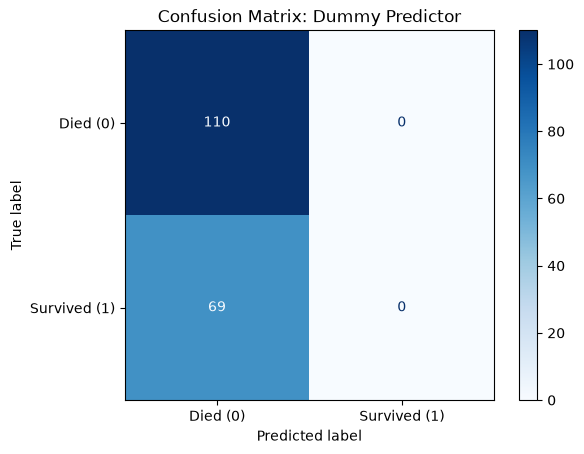

In [12]:
"""
Module: Model Diagnostics (Confusion Matrix)
Purpose: Visually maps True Positives, True Negatives, False Positives, and False Negatives.
"""

# Generate the Confusion Matrix array
cm = confusion_matrix(y_test_tit, dummy_predictions)

# Initialize the visualizer with our labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Died (0)', 'Survived (1)'])

# Plot it using a blue color map
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: Dummy Predictor")
plt.show()
